<a href="https://colab.research.google.com/github/ongsoony8382/financial-data-programming/blob/main/5%EC%A3%BC%EC%B0%A8_%EA%B8%88%EC%9C%B5%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D(1)_%EB%8F%99%EC%98%81%EC%83%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 학습목표
금융데이터의 구조를 살펴보고 Numpy 라이브러리에 대하여 학습한다.

# 학습내용
금융데이터 구조
Numpy 라이브러리


# 삼성전자 주가 분석

# 필수 도구 설치 (Installation)
금융 데이터를 가져오는 가장 유명한 라이브러리인 yfinance를 설치. (터미널이나 주피터 노트북 셀에서 실행)

In [ ]:
# 주피터 노트북에서는 앞에 !를 붙여 실행
!pip install yfinance

# 데이터 가져오기 (Data Fetching)
한국 주식은 종목 코드 뒤에 .KS (코스피) 또는 .KQ (코스닥)를 붙여야 함.
삼성전자: 005930.KS
애플: AAPL (미국 주식은 티커 그대로 사용)

In [2]:
import yfinance as yf
import pandas as pd

# 1. 삼성전자(005930.KS)의 2020년부터 현재까지 데이터 다운로드
ticker = "005930.KS"
print(f"{ticker} 데이터를 다운로드 중입니다...")

df = yf.download(ticker, start="2020-01-01")

# 2. 데이터 잘 가져왔는지 확인 (상위 5개 행 출력)
print("\n[데이터 미리보기]")
print(df.head())

005930.KS 데이터를 다운로드 중입니다...


/tmp/ipykernel_1475/448595852.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


[데이터 미리보기]
Price              Close          High           Low          Open    Volume
Ticker         005930.KS     005930.KS     005930.KS     005930.KS 005930.KS
Date                                                                        
2020-01-02  47470.902344  48158.886436  47298.906321  47728.896378  12993228
2020-01-03  47728.898438  48674.876605  47212.910346  48158.888514  15422255
2020-01-06  47728.898438  47814.896453  46954.916301  47212.910346  10278951
2020-01-07  47986.886719  48502.874748  47814.890709  47900.888714  10009778
2020-01-08  48846.863281  49362.851274  48072.881293  48330.875289  23501171


# 데이터 구조 확인 (Inspection)
우리가 배운 OHLCV 구조가 실제로 어떻게 되어 있는지 확인

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1532 entries, 2020-01-02 to 2026-04-03
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   1532 non-null   float64
 1   (High, 005930.KS)    1532 non-null   float64
 2   (Low, 005930.KS)     1532 non-null   float64
 3   (Open, 005930.KS)    1532 non-null   float64
 4   (Volume, 005930.KS)  1532 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.8 KB
None



# 데이터 시각화 (Visualization)
그래프를 그려 주가의 흐름을 확인

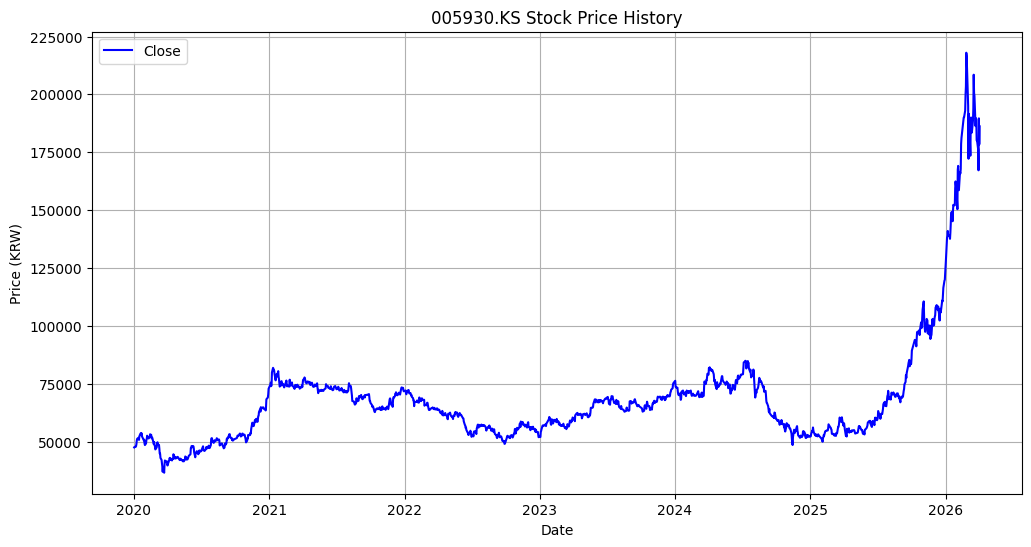

In [5]:
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.figure(figsize=(12,6))
plt.title(f"{ticker} Stock Price History")

# 주가(Close) 그리기
plt.plot(df.index, df['Close'], label='Close', color='blue')

# 그래프 레이블 및 범례 추가
plt.xlabel('Date')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


# 테슬라의 수익률 분석
종목: 테슬라(TSLA) 데이터를 가져오기
기간: start 날짜를 나의 생일로 바꾸기.
수익률 계산: df['Adj Close'].pct_change() 함수를 사용하여 일일 수익률을 구하기.

In [11]:
import yfinance as yf
import pandas as pd

# 1. 테슬라의 데이터 다운로드
ticker = "TSLA"
print(f"{ticker} 데이터를 다운로드 중입니다...")

df = yf.download(ticker, start = "2025-01-01")

# 2. 데이터 잘 가져왔는지 확인 (상위 5개 행 출력)
print("\n[데이터 미리보기]")
print(df.head())

# 데이터의 정보 확인 (행/열 개수, 데이터 타입, 결측치 유무)
print(df.info())

/tmp/ipykernel_1475/450246769.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start = "2025-01-01")
[*********************100%***********************]  1 of 1 completed

TSLA 데이터를 다운로드 중입니다...

[데이터 미리보기]
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2025-01-02  379.279999  392.730011  373.040009  390.100006  109710700
2025-01-03  410.440002  411.880005  379.450012  381.480011   95423300
2025-01-06  411.049988  426.429993  401.700012  423.200012   85516500
2025-01-07  394.359985  414.329987  390.000000  405.829987   75699500
2025-01-08  394.940002  402.500000  387.399994  392.950012   73038800
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 313 entries, 2025-01-02 to 2026-04-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   313 non-null    float64
 1   (High, TSLA)    313 non-null    float64
 2   (Low, TSLA)     313 non-null    float64
 3   (Open, TSLA)    313 non-null    float64
 4   (Volume

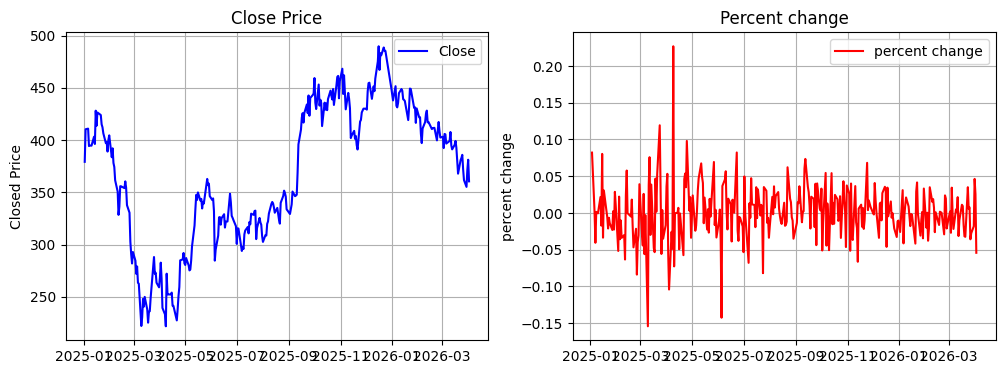

In [12]:
import matplotlib.pyplot as plt

# 1행 2열의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4)) # (행, 열, 크기)

# 첫 번째 그래프 (ax1)
ax1.plot(df.index, df['Close'], label='Close', color='blue')
ax1.set_title("Close Price")
ax1.set_ylabel("Closed Price")
ax1.grid(True)
ax1.legend()

# 두 번째 그래프 (ax2)
ax2.plot(df.index, df['Close'].pct_change(), label='percent change', color='red')
ax2.set_title('Percent change')
ax2.set_ylabel('percent change')
ax2.grid(True)
ax2.legend()

# 레이아웃 자동 조절
plt.tight_layout

# 그래프 표시
plt.show()